In [1]:
# EDA & Core Training (Target: NSL-KDD)
# Trains GCN, GAT, and GraphSAGE on NSL-KDD and saves models + scaler for cross-dataset evaluation.

In [2]:
# --- Cell 1: Setup ---
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import joblib

from torch_geometric.nn import GCNConv, GATConv, SAGEConv
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

print('Setup complete.')

Setup complete.


In [3]:
# --- Cell 2: EDA & Loading ---
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land',
    'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'attack_type', 'difficulty_level'
]

df = pd.read_csv('KDDTrain+.txt', names=columns, header=None)
df = df.dropna(subset=['attack_type'])
df['label'] = (df['attack_type'] != 'normal').astype(int)

if df['label'].isnull().any():
    print('Warning: NaNs found in labels! Dropping them...')
    df = df.dropna(subset=['label'])

print(f'Total rows after cleaning: {len(df)}')
print(f'Label distribution:\n{df["label"].value_counts()}')

y = df['label'].values

Total rows after cleaning: 125973
Label distribution:
label
0    67343
1    58630
Name: count, dtype: int64


In [4]:
# --- Cell 3: Feature Alignment ---
# These 5 features exist natively in NSL-KDD and are mapped from UNSW/CICIDS in the eval notebooks.
COMMON_FEATURES = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count']

X = df[COMMON_FEATURES].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save the scaler so evaluation notebooks can apply the same transformation
joblib.dump(scaler, 'ids_scaler.pkl')
print('Scaler saved successfully!')

if np.isnan(X_scaled).any() or np.isnan(y).any():
    print('CRITICAL: NaNs still exist in X or y!')
else:
    print('Data is clean. Proceeding to graph construction...')

Scaler saved successfully!
Data is clean. Proceeding to graph construction...


In [5]:
# --- Cell 4: Graph Construction ---
# NSL-KDD has no real IP columns. We use SEQUENTIAL edges (row i -> row i+1),
# which is a standard approach for flow-based datasets without network topology.
# This ensures num_nodes == len(df), so x, y, and edge_index are all consistent.

def create_graph_data(X_values, y_values):
    num_nodes = len(y_values)

    # Sequential chain edges: 0->1, 1->2, ..., (N-2)->(N-1)
    src_nodes = np.arange(0, num_nodes - 1)
    dst_nodes = np.arange(1, num_nodes)
    edge_index = torch.tensor([src_nodes, dst_nodes], dtype=torch.long)

    # Train/test split
    train_idx, test_idx = train_test_split(
        np.arange(num_nodes), test_size=0.2, stratify=y_values, random_state=42
    )
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask  = torch.zeros(num_nodes, dtype=torch.bool)
    train_mask[train_idx] = True
    test_mask[test_idx]   = True

    return Data(
        x=torch.tensor(X_values, dtype=torch.float),
        edge_index=edge_index,
        y=torch.tensor(y_values, dtype=torch.long),
        train_mask=train_mask,
        test_mask=test_mask
    )

data = create_graph_data(X_scaled, y)
print(f'Graph: {data.num_nodes} nodes, {data.num_edges} edges')
print(f'Train nodes: {data.train_mask.sum().item()}, Test nodes: {data.test_mask.sum().item()}')

Graph: 125973 nodes, 125972 edges
Train nodes: 100778, Test nodes: 25195


C:\Users\ceb1003\AppData\Local\Temp\ipykernel_26788\1173102843.py:12: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  edge_index = torch.tensor([src_nodes, dst_nodes], dtype=torch.long)


In [6]:
# --- Cell 5: GNN Model Definition ---
class GNNModel(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, model_type='GCN'):
        super(GNNModel, self).__init__()
        self.model_type = model_type
        if model_type == 'GCN':
            self.conv1 = GCNConv(input_dim, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, output_dim)
        elif model_type == 'GAT':
            self.conv1 = GATConv(input_dim, hidden_dim, heads=8, concat=True)
            self.conv2 = GATConv(hidden_dim * 8, output_dim, heads=1, concat=False)
        elif model_type == 'SAGE':
            self.conv1 = SAGEConv(input_dim, hidden_dim)
            self.conv2 = SAGEConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

In [7]:
# --- Cell 6: Evaluate Function ---
@torch.no_grad()
def evaluate(model, data):
    model.eval()
    logits = model(data)
    preds  = logits[data.test_mask].argmax(dim=1)
    y_true = data.y[data.test_mask]
    return {
        'accuracy':  accuracy_score(y_true.cpu(), preds.cpu()),
        'f1':        f1_score(y_true.cpu(), preds.cpu(), zero_division=0),
        'precision': precision_score(y_true.cpu(), preds.cpu(), zero_division=0),
        'recall':    recall_score(y_true.cpu(), preds.cpu(), zero_division=0)
    }

In [8]:
# --- Cell 7: Training ---
model_types = ['GCN', 'GAT', 'SAGE']
comparison_results = {}

input_dim  = X_scaled.shape[1]  # 5
hidden_dim = 64
output_dim = 2  # Binary: Normal (0) or Attack (1)

for m_type in model_types:
    print(f'\n--- Training {m_type} ---')
    model     = GNNModel(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, model_type=m_type)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    # Class weight: penalise missed attacks 2x more than false alarms
    weights   = torch.tensor([1.0, 2.0])
    criterion = torch.nn.CrossEntropyLoss(weight=weights)

    model.train()
    for epoch in range(1, 101):
        optimizer.zero_grad()
        out  = model(data)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        if epoch % 20 == 0:
            print(f'  Epoch {epoch:03d} | Loss: {loss.item():.4f}')

    comparison_results[m_type] = evaluate(model, data)
    torch.save(model.state_dict(), f'gnn_model_{m_type.lower()}.pt')
    print(f'  Saved gnn_model_{m_type.lower()}.pt')

print('\nAll models trained and saved!')


--- Training GCN ---
  Epoch 020 | Loss: 0.6231
  Epoch 040 | Loss: 0.6191
  Epoch 060 | Loss: 0.6169
  Epoch 080 | Loss: 0.6162
  Epoch 100 | Loss: 0.6156
  Saved gnn_model_gcn.pt

--- Training GAT ---
  Epoch 020 | Loss: 0.5838
  Epoch 040 | Loss: 0.5500
  Epoch 060 | Loss: 0.5057
  Epoch 080 | Loss: 0.4798
  Epoch 100 | Loss: 0.4631
  Saved gnn_model_gat.pt

--- Training SAGE ---
  Epoch 020 | Loss: 0.4098
  Epoch 040 | Loss: 0.3686
  Epoch 060 | Loss: 0.3456
  Epoch 080 | Loss: 0.3345
  Epoch 100 | Loss: 0.3297
  Saved gnn_model_sage.pt

All models trained and saved!


In [9]:
# --- Cell 8: Per-Model Results ---
print('NSL-KDD Test Set Results:')
for m_type, metrics in comparison_results.items():
    print(f'\n{m_type}:')
    for metric, value in metrics.items():
        print(f'  {metric.capitalize()}: {value:.4f}')

NSL-KDD Test Set Results:

GCN:
  Accuracy: 0.6180
  F1: 0.6841
  Precision: 0.5561
  Recall: 0.8886

GAT:
  Accuracy: 0.7307
  F1: 0.7320
  Precision: 0.6817
  Recall: 0.7902

SAGE:
  Accuracy: 0.8820
  F1: 0.8597
  Precision: 0.9622
  Recall: 0.7770


      accuracy        f1  precision    recall
GCN   0.617980  0.684064   0.556060  0.888624
GAT   0.730661  0.731969   0.681725  0.790210
SAGE  0.882000  0.859731   0.962192  0.776991


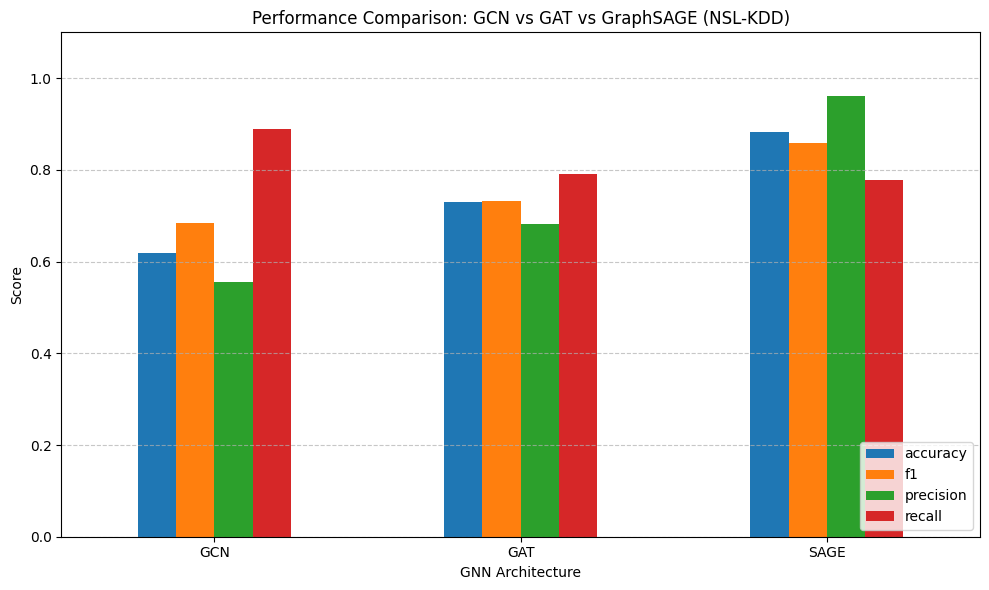

In [10]:
# --- Cell 9: Comparison Plot ---
df_compare = pd.DataFrame(comparison_results).T
print(df_compare)

fig, ax = plt.subplots(figsize=(10, 6))
df_compare.plot(kind='bar', ax=ax)
ax.set_title('Performance Comparison: GCN vs GAT vs GraphSAGE (NSL-KDD)')
ax.set_ylabel('Score')
ax.set_xlabel('GNN Architecture')
ax.set_ylim(0, 1.1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()